In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
df = pd.read_csv("parkinsons.data")
df = df.drop(['name'], axis=1)

X = df.drop('status', axis=1).values
y = df['status'].values

In [3]:
df.head()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [4]:
df.isna().sum()

MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

<Axes: xlabel='status', ylabel='count'>

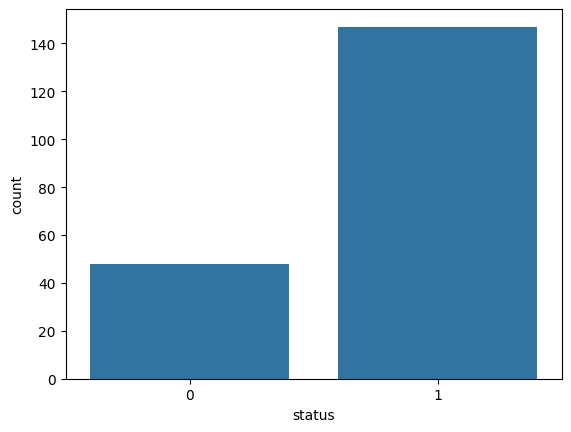

In [5]:
sns.countplot(x="status",data=df)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [9]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

svm_pca = SVC(kernel='rbf', probability=True)
svm_pca.fit(X_train_pca, y_train_smote)

y_pred_pca = svm_pca.predict(X_test_pca)
y_prob_pca = svm_pca.predict_proba(X_test_pca)[:, 1]

In [10]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [11]:
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(SparseAutoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )
        
    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent

In [12]:
input_dim = X_train_scaled.shape[1]
model = SparseAutoencoder(input_dim)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

l1_lambda = 1e-4

In [13]:
epochs = 100

for epoch in range(epochs):
    total_loss = 0
    
    for data_batch, _ in train_loader:
        
        optimizer.zero_grad()
        
        reconstructed, latent = model(data_batch)
        
        mse_loss = criterion(reconstructed, data_batch)
        
        l1_loss = torch.mean(torch.abs(latent))
        
        loss = mse_loss + l1_lambda * l1_loss
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 14.8903
Epoch 2, Loss: 13.4908
Epoch 3, Loss: 9.6900
Epoch 4, Loss: 6.0713
Epoch 5, Loss: 5.1258
Epoch 6, Loss: 4.5254
Epoch 7, Loss: 4.1260
Epoch 8, Loss: 3.8212
Epoch 9, Loss: 3.6613
Epoch 10, Loss: 3.5800
Epoch 11, Loss: 3.5014
Epoch 12, Loss: 3.3770
Epoch 13, Loss: 3.2875
Epoch 14, Loss: 3.1989
Epoch 15, Loss: 3.0467
Epoch 16, Loss: 2.9435
Epoch 17, Loss: 2.7385
Epoch 18, Loss: 2.5920
Epoch 19, Loss: 2.4384
Epoch 20, Loss: 2.2803
Epoch 21, Loss: 2.1520
Epoch 22, Loss: 2.0096
Epoch 23, Loss: 1.9124
Epoch 24, Loss: 1.8334
Epoch 25, Loss: 1.7788
Epoch 26, Loss: 1.6679
Epoch 27, Loss: 1.5645
Epoch 28, Loss: 1.4871
Epoch 29, Loss: 1.4459
Epoch 30, Loss: 1.3849
Epoch 31, Loss: 1.3380
Epoch 32, Loss: 1.2747
Epoch 33, Loss: 1.2207
Epoch 34, Loss: 1.1800
Epoch 35, Loss: 1.1479
Epoch 36, Loss: 1.1098
Epoch 37, Loss: 1.0922
Epoch 38, Loss: 1.1321
Epoch 39, Loss: 1.0528
Epoch 40, Loss: 1.0111
Epoch 41, Loss: 0.9533
Epoch 42, Loss: 0.9198
Epoch 43, Loss: 0.9170
Epoch 44, Loss: 0.

In [14]:
model.eval()

with torch.no_grad():
    X_train_sae = model.encoder(torch.tensor(X_train_scaled, dtype=torch.float32)).numpy()
    X_test_sae = model.encoder(torch.tensor(X_test_scaled, dtype=torch.float32)).numpy()

In [15]:
svm_sae = SVC(kernel='rbf', probability=True)
svm_sae.fit(X_train_sae, y_train_smote)

y_pred_sae = svm_sae.predict(X_test_sae)
y_prob_sae = svm_sae.predict_proba(X_test_sae)[:, 1]

In [16]:
def evaluate_model(y_test, y_pred, y_prob):
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)

    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("MCC:", mcc)
    print("PR AUC:", pr_auc)

In [17]:
print("PCA-SVM Results")
evaluate_model(y_test, y_pred_pca, y_prob_pca)

print("\nSAE-SVM Results")
evaluate_model(y_test, y_pred_sae, y_prob_sae)

PCA-SVM Results
Accuracy: 0.8205128205128205
F1 Score: 0.8627450980392157
MCC: 0.6680175630198975
PR AUC: 0.9751365586563356

SAE-SVM Results
Accuracy: 0.8205128205128205
F1 Score: 0.8627450980392157
MCC: 0.6680175630198975
PR AUC: 0.9865302602971455
